# NBA Injury Recovery Performance Modeler

**Quantifying how players perform across recovery windows after specific injury types and predicting full recovery timelines.**

---

## Project Purpose

Most NBA analytics work tries to predict *whether* an injury will happen. This notebook asks the more practical question: *what happens after?* When a player returns from an ankle sprain, how many games until they play like themselves again? Does that answer change for a hamstring strain, an ACL reconstruction, a concussion?

Brief Overview of Five Connected Steps:

1. **Build the injury event dataset** — turn a stream of daily injury-report snapshots into a clean event log (one row per OUT-and-return), and join it to per-game performance stats.
2. **NLP injury classification** — collapse messy free-text reasons (e.g. "left ankle sprain", "ankle - injury management", "right ankle soreness") into a clean taxonomy.
3. **Performance delta analysis** — for each return event, compare post-return play to pre-injury baseline using paired t-tests and Cohen's d across multiple game windows (1–5, 6–10, 11–20).
4. **Survival analysis** — model time-to-full-recovery with Kaplan-Meier curves by injury type and Cox Regression to identify which player factors predict faster or slower recovery.
5. **DTW clustering of recovery trajectories** — use Dynamic Time Warping to discover *recovery archetypes* (fast recoverers, slow recoverers, performance dippers, performance bouncers) without pre-specifying labels.

## Setup: imports and configuration

We rely on the standard scientific Python stack plus two specialty libraries:

- **`lifelines`** for survival analysis (Kaplan-Meier estimator, Cox Proportional Hazards regression)
- **`tslearn`** for time-series clustering with the Dynamic Time Warping (DTW) distance metric

If you don't have them, run: `pip install lifelines tslearn`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Reproducibility
RNG = np.random.default_rng(seed=42)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

print('Imports loaded. Ready to build the dataset.')

Imports loaded. Ready to build the dataset.


---

# Step 1. Building the Injury Event Dataset

The raw injury-report data is a daily stream of *player-status snapshots*. We need to flip this into an **event log** — one row per injury, with when the player went out, when they returned, and their pre/post performance.

## Production code (live data fetch)

The code below fetches real injury data from `nbainjuries` and `nba_api`. This is what you'd run in production.

In [9]:
import time
import sqlite3
from datetime import datetime, timedelta
from nbainjuries import injury
from nba_api.stats.endpoints import playergamelog, commonplayerinfo
from nba_api.stats.static import players
import os

CACHE = sqlite3.connect('nba_cache.db')

def fetch_injury_reports(seasons=('2023-24', '2024-25')):
    """
    Fetch injury reports by generating timestamps for each season.
    Reports are timestamped hourly at 5:30 PM ET.
    """
    frames = []
    
    # Season start dates (adjusted to actual NBA season openers)
    season_dates = {
        '2021-22': (datetime(2021, 10, 19), datetime(2022, 6, 30)),
        '2022-23': (datetime(2022, 10, 18), datetime(2023, 6, 30)),
        '2023-24': (datetime(2023, 10, 24), datetime(2024, 6, 30)),
        '2024-25': (datetime(2024, 10, 22), datetime(2025, 6, 30)),
    }
    
    for season in seasons:
        start_date, end_date = season_dates[season]
        current = start_date.replace(hour=17, minute=30)
        
        while current <= end_date:
            if injury.check_reportvalid(current):
                try:
                    report = injury.get_reportdata(current, return_df=True)
                    if report is not None and len(report) > 0:
                        report['season'] = season
                        report['report_date'] = current
                        frames.append(report)
                        print(f"✓ Fetched {season} report for {current.date()}: {len(report)} entries")
                except Exception as e:
                    print(f"✗ Failed {season} {current.date()}: {e}")
            
            time.sleep(0.5)  # Rate limiting
            current += timedelta(days=1)
        
        print(f"Completed season {season}\n")
    
    if frames:
        return pd.concat(frames, ignore_index=True)
    else:
        return pd.DataFrame()

def collapse_to_events(df):
    """
    Turn daily snapshots into one row per OUT-streak.
    Column names from nbainjuries: 'Player Name', 'Game Date', 'Current Status', 'Reason', 'Team'
    """
    df['Game Date'] = pd.to_datetime(df['Game Date'])
    df = df.sort_values(['Player Name', 'Game Date'])
    
    # Mark OUT status
    df['is_out'] = (df['Current Status'] == 'Out').astype(int)
    
    # Create streak IDs for consecutive OUT periods
    df['streak_id'] = (df['is_out'].diff() == 1).groupby(df['Player Name']).cumsum()
    
    # Aggregate OUT streaks
    out_streaks = df[df['is_out'] == 1].groupby(['Player Name', 'streak_id']).agg(
        out_date=('Game Date', 'min'),
        last_out_date=('Game Date', 'max'),
        reason=('Reason', lambda s: s.mode().iat[0] if len(s.mode()) > 0 else s.iloc[0]),
        team=('Team', 'first'),
        season=('season', 'first'),
    ).reset_index()
    
    # Filter out non-injuries: rest, load management, G-League assignments, etc.
    mask = ~out_streaks['reason'].str.lower().str.contains(
        'rest|load|personal|not injury|g league|two-way',
        na=False,
        regex=True
    )
    
    return out_streaks[mask].copy()

def get_player_id(player_name):
    """
    Look up NBA player ID from name.
    Handles both "First Last" and "Last, First" formats.
    """
    all_players = players.get_players()
    
    # Reverse "Last, First" to "First Last"
    if ',' in player_name:
        parts = player_name.split(',')
        if len(parts) == 2:
            player_name = f"{parts[1].strip()} {parts[0].strip()}"
    
    # Exact match
    matches = [p for p in all_players if p['full_name'].lower() == player_name.lower()]
    if matches:
        return matches[0]['id']
    
    # Partial match
    matches = [p for p in all_players if player_name.lower() in p['full_name'].lower()]
    if matches:
        return matches[0]['id']
    
    return None

def get_player_birthdate(player_id, max_retries=3):
    """Fetch player birth date with retry logic."""
    for attempt in range(max_retries):
        try:
            info = commonplayerinfo.CommonPlayerInfo(player_id=player_id).get_data_frames()[0]
            birthdate_str = info['BIRTHDATE'].iloc[0]
            
            if pd.notna(birthdate_str):
                birthdate = pd.to_datetime(birthdate_str.split('T')[0])
                return birthdate
            return None
            
        except Exception as e:
            if attempt < max_retries - 1:
                wait_time = (attempt + 1) * 2
                time.sleep(wait_time)
            else:
                return None
    return None

def calculate_age(birthdate, injury_date):
    """Calculate age in years at the time of injury."""
    if pd.isna(birthdate) or pd.isna(injury_date):
        return None
    
    birthdate = pd.to_datetime(birthdate)
    injury_date = pd.to_datetime(injury_date)
    
    age = injury_date.year - birthdate.year
    if (injury_date.month, injury_date.day) < (birthdate.month, birthdate.day):
        age -= 1
    
    return age

def attach_game_logs(events, save_every=10, output_file='nba_injury_analysis.csv'):
    """
    For each injury event, fetch game logs and compute pre/post performance.
    CRITICAL FIX: Fetches game logs for the correct season.
    Saves progress incrementally and can resume from where it left off.
    """
    enriched = []
    
    # Check for existing progress
    already_processed = set()
    if os.path.exists(output_file):
        existing_df = pd.read_csv(output_file)
        already_processed = set(existing_df['player_name'] + '_' + existing_df['out_date'].astype(str))
        enriched = existing_df.to_dict('records')
        print(f"📂 Found existing file with {len(enriched)} events. Resuming...\n")
    
    print(f"Processing {len(events)} injury events ({len(already_processed)} already done)...\n")
    
    for idx, ev in events.iterrows():
        event_key = f"{ev['Player Name']}_{ev['out_date']}"
        
        # Skip if already processed
        if event_key in already_processed:
            continue
        
        print(f"[{idx+1}/{len(events)}] Processing {ev['Player Name']}...")
        
        player_id = get_player_id(ev['Player Name'])
        if player_id is None:
            print(f"  ⚠ Skipping - player not found")
            continue
        
        # CRITICAL: Get the injury season
        injury_season = ev.get('season', '2023-24')
        
        # Fetch game logs for the CORRECT SEASON
        try:
            logs = playergamelog.PlayerGameLog(
                player_id=player_id,
                season=injury_season  # ← THIS IS THE FIX
            ).get_data_frames()[0]
            time.sleep(0.8)
        except Exception as e:
            print(f"  ✗ Failed to fetch logs: {str(e)[:100]}")
            continue
        
        try:
            logs['GAME_DATE'] = pd.to_datetime(logs['GAME_DATE'])
            
            # Games before injury
            pre = logs[logs['GAME_DATE'] < ev.out_date].head(10)
            # Games after return
            post = logs[logs['GAME_DATE'] > ev.last_out_date].head(20)
            
            if len(pre) >= 5 and len(post) >= 5:
                enriched.append({
                    'player_name': ev['Player Name'],
                    'team': ev['team'],
                    'season': injury_season,
                    'injury_reason': ev['reason'],
                    'out_date': ev['out_date'],
                    'return_date': ev['last_out_date'],
                    'days_out': (ev['last_out_date'] - ev['out_date']).days,
                    
                    # Pre-injury stats
                    'pre_avg_pts': pre['PTS'].mean(),
                    'pre_avg_reb': pre['REB'].mean(),
                    'pre_avg_ast': pre['AST'].mean(),
                    'pre_avg_min': pre['MIN'].mean(),
                    
                    # Post-injury stats
                    'post_pts': post['PTS'].tolist(),
                    'post_reb': post['REB'].tolist(),
                    'post_ast': post['AST'].tolist(),
                    'post_min': post['MIN'].tolist(),
                    
                    'post_avg_pts': post['PTS'].mean(),
                    'post_avg_reb': post['REB'].mean(),
                    'post_avg_ast': post['AST'].mean(),
                    'post_avg_min': post['MIN'].mean(),
                })
                print(f"  ✓ Success: {len(pre)} pre, {len(post)} post games")
            else:
                print(f"  ⚠ Skipping - insufficient data (pre: {len(pre)}, post: {len(post)})")
        
        except Exception as e:
            print(f"  ✗ Error: {str(e)[:100]}")
            continue
        
        # Save progress
        if len(enriched) > 0 and (len(enriched) - len(already_processed)) % save_every == 0:
            df_temp = pd.DataFrame(enriched)
            df_temp.to_csv(output_file, index=False)
            print(f"  💾 Saved progress: {len(enriched)} events total\n")
    
    # Final save
    final_df = pd.DataFrame(enriched)
    if len(final_df) > 0:
        final_df.to_csv(output_file, index=False)
        print(f"\n✅ Final save: {len(final_df)} injury recovery events")
    
    return final_df

def add_real_ages(df, cache_file='player_birthdates_cache.csv'):
    """
    Add real player ages to the dataframe.
    Uses a cache file to avoid re-fetching birth dates.
    """
    # Try to load cached birth dates
    try:
        birthdate_cache = pd.read_csv(cache_file)
        birthdate_cache['birthdate'] = pd.to_datetime(birthdate_cache['birthdate'])
        print(f"📂 Loaded {len(birthdate_cache)} cached birth dates")
    except FileNotFoundError:
        birthdate_cache = pd.DataFrame(columns=['player_name', 'player_id', 'birthdate'])
        print("No cache found, will fetch all birth dates")
    
    unique_players = df['player_name'].unique()
    print(f"\nFetching birth dates for {len(unique_players)} unique players...")
    
    new_birthdates = []
    
    for idx, player_name in enumerate(unique_players):
        # Check cache
        cached = birthdate_cache[birthdate_cache['player_name'] == player_name]
        if len(cached) > 0:
            print(f"[{idx+1}/{len(unique_players)}] {player_name} - cached")
            continue
        
        print(f"[{idx+1}/{len(unique_players)}] Fetching {player_name}...")
        
        player_id = get_player_id(player_name)
        if player_id is None:
            print(f"  ⚠ Player ID not found")
            new_birthdates.append({'player_name': player_name, 'player_id': None, 'birthdate': None})
            continue
        
        birthdate = get_player_birthdate(player_id)
        if birthdate:
            print(f"  ✓ Born: {birthdate.date()}")
            new_birthdates.append({'player_name': player_name, 'player_id': player_id, 'birthdate': birthdate})
        else:
            print(f"  ⚠ Birth date not available")
            new_birthdates.append({'player_name': player_name, 'player_id': player_id, 'birthdate': None})
        
        time.sleep(0.8)
        
        # Save progress every 10 players
        if len(new_birthdates) > 0 and len(new_birthdates) % 10 == 0:
            temp_cache = pd.concat([birthdate_cache, pd.DataFrame(new_birthdates)], ignore_index=True)
            temp_cache.to_csv(cache_file, index=False)
            print(f"  💾 Saved progress\n")
    
    # Combine cache with new data
    if new_birthdates:
        birthdate_cache = pd.concat([birthdate_cache, pd.DataFrame(new_birthdates)], ignore_index=True)
        birthdate_cache.to_csv(cache_file, index=False)
        print(f"\n✅ Saved complete birth date cache: {len(birthdate_cache)} players")
    
    # Merge with injury data
    df = df.merge(birthdate_cache[['player_name', 'birthdate']], on='player_name', how='left')
    
    # Calculate age at injury
    df['age'] = df.apply(lambda row: calculate_age(row['birthdate'], row['out_date']), axis=1)
    
    print(f"\n📊 Age statistics:")
    print(f"  - Events with age data: {df['age'].notna().sum()} / {len(df)}")
    print(f"  - Age range: {df['age'].min():.0f} - {df['age'].max():.0f}")
    print(f"  - Mean age: {df['age'].mean():.1f}")
    
    df = df.drop('birthdate', axis=1)
    return df

def extract_injury_type(reason):
    """Extract injury type from free-text reason."""
    if pd.isna(reason):
        return 'Unknown'
    
    reason_lower = reason.lower()
    
    # Order matters - check specific before general
    if 'knee' in reason_lower:
        return 'Knee'
    elif 'ankle' in reason_lower:
        return 'Ankle'
    elif 'hamstring' in reason_lower:
        return 'Hamstring'
    elif 'back' in reason_lower or 'spine' in reason_lower:
        return 'Back'
    elif 'shoulder' in reason_lower:
        return 'Shoulder'
    elif 'hip' in reason_lower:
        return 'Hip'
    elif 'foot' in reason_lower or 'toe' in reason_lower:
        return 'Foot'
    elif 'hand' in reason_lower or 'finger' in reason_lower or 'wrist' in reason_lower:
        return 'Hand/Wrist'
    elif 'calf' in reason_lower:
        return 'Calf'
    elif 'groin' in reason_lower:
        return 'Groin'
    elif 'quad' in reason_lower:
        return 'Quadriceps'
    elif 'illness' in reason_lower or 'flu' in reason_lower or 'covid' in reason_lower:
        return 'Illness'
    elif 'concussion' in reason_lower or 'head' in reason_lower:
        return 'Concussion'
    else:
        return 'Other'
def extract_laterality(text):
    """Extract left/right/bilateral from injury text."""
    if not isinstance(text, str):
        return None
    t = text.lower()
    if 'bilateral' in t: return 'bilateral'
    if 'left' in t: return 'left'
    if 'right' in t: return 'right'
    return None

## Run the data pipeline

Execute the steps below to fetch injury data, collapse it to events, enrich with game logs and ages, and save the final dataset.

In [3]:
# Step 1: Fetch injury reports
injury_df = fetch_injury_reports(seasons=('2023-24', '2024-25'))
print(f"\nFetched {len(injury_df)} injury report entries")

Validated Injury-Report_2023-10-24_05PM.
Validated Injury-Report_2023-10-24_05PM.
✓ Fetched 2023-24 report for 2023-10-24: 59 entries
Validated Injury-Report_2023-10-25_05PM.
Validated Injury-Report_2023-10-25_05PM.
✓ Fetched 2023-24 report for 2023-10-25: 57 entries
Validated Injury-Report_2023-10-26_05PM.
Validated Injury-Report_2023-10-26_05PM.
✓ Fetched 2023-24 report for 2023-10-26: 52 entries
Validated Injury-Report_2023-10-27_05PM.
Validated Injury-Report_2023-10-27_05PM.
✓ Fetched 2023-24 report for 2023-10-27: 75 entries
Validated Injury-Report_2023-10-28_05PM.
Validated Injury-Report_2023-10-28_05PM.
✓ Fetched 2023-24 report for 2023-10-28: 70 entries
Validated Injury-Report_2023-10-29_05PM.
Validated Injury-Report_2023-10-29_05PM.
✓ Fetched 2023-24 report for 2023-10-29: 82 entries
Validated Injury-Report_2023-10-30_05PM.
Validated Injury-Report_2023-10-30_05PM.
✓ Fetched 2023-24 report for 2023-10-30: 95 entries
Validated Injury-Report_2023-10-31_05PM.
Validated Injury-Repo

In [4]:
# Step 2: Collapse to injury events
events_df = collapse_to_events(injury_df)
print(f"Found {len(events_df)} injury events to process\n")

Found 2076 injury events to process



In [5]:
# Step 3: Attach game logs (this takes a while - saves progress incrementally)
final_df = attach_game_logs(
    events_df,
    save_every=5,
    output_file='nba_injury_analysis_v2.csv'
)

print(f"\n✓ Complete! {len(final_df)} events exported")

Processing 2076 injury events (0 already done)...

[1/2076] Processing Achiuwa, Precious...
  ⚠ Skipping - insufficient data (pre: 3, post: 20)
[2/2076] Processing Achiuwa, Precious...
  ⚠ Skipping - insufficient data (pre: 3, post: 20)
[3/2076] Processing Achiuwa, Precious...
  ⚠ Skipping - insufficient data (pre: 10, post: 0)
[4/2076] Processing Adams, Steven...
  ⚠ Skipping - insufficient data (pre: 0, post: 0)
[5/2076] Processing Adams, Steven...
  ⚠ Skipping - insufficient data (pre: 0, post: 20)
[6/2076] Processing Adams, Steven...
  ⚠ Skipping - insufficient data (pre: 2, post: 20)
[7/2076] Processing Adams, Steven...
  ⚠ Skipping - insufficient data (pre: 3, post: 20)
[8/2076] Processing Adams, Steven...
  ⚠ Skipping - insufficient data (pre: 4, post: 20)
[9/2076] Processing Adams, Steven...
  ✓ Success: 6 pre, 20 post games
[10/2076] Processing Adams, Steven...
  ✓ Success: 10 pre, 20 post games
[11/2076] Processing Adams, Steven...
  ✓ Success: 10 pre, 19 post games
[12/2076]

In [6]:
# Step 4: Add real player ages (cached)
final_df = add_real_ages(final_df)

📂 Loaded 203 cached birth dates

Fetching birth dates for 392 unique players...
[1/392] Adams, Steven - cached
[2/392] Adebayo, Bam - cached
[3/392] Agbaji, Ochai - cached
[4/392] Aldama, Santi - cached
[5/392] Allen, Grayson - cached
[6/392] Alvarado, Jose - cached
[7/392] Anderson, Kyle - cached
[8/392] Antetokounmpo, Giannis - cached
[9/392] Anthony, Cole - cached
[10/392] Anunoby, OG - cached
[11/392] Avdija, Deni - cached
[12/392] Ayton, Deandre - cached
[13/392] Bagley III, Marvin - cached
[14/392] Baldwin Jr., Patrick - cached
[15/392] Ball, LaMelo - cached
[16/392] Ball, Lonzo - cached
[17/392] Bamba, Mo - cached
[18/392] Banchero, Paolo - cached
[19/392] Bane, Desmond - cached
[20/392] Banton, Dalano - cached
[21/392] Barnes, Scottie - cached
[22/392] Barrett, RJ - cached
[23/392] Batum, Nicolas - cached
[24/392] Beal, Bradley - cached
[25/392] Beasley, Malik - cached
[26/392] Beauchamp, MarJon - cached
[27/392] Bertans, Davis - cached
[28/392] Beverley, Patrick - cached
[29/3

In [10]:
# Step 5: Add injury classification + games missed, save complete dataset
final_df['injury_type'] = final_df['injury_reason'].apply(extract_injury_type)
final_df['laterality'] = final_df['injury_reason'].apply(extract_laterality)
final_df['games_missed'] = (final_df['days_out'] / 2).round().astype(int)

final_df.to_csv('nba_injury_analysis_complete.csv', index=False)
print(f"✓ Saved complete dataset: {len(final_df)} events")
print(f"\nInjury type distribution:")
print(final_df['injury_type'].value_counts())

✓ Saved complete dataset: 1179 events

Injury type distribution:
injury_type
Illness       276
Ankle         237
Knee          159
Back           76
Foot           75
Other          63
Hip            55
Hamstring      55
Calf           53
Hand/Wrist     39
Shoulder       28
Groin          26
Concussion     20
Quadriceps     17
Name: count, dtype: int64


## Dataset Overview

Let's look at the injury distribution and games missed by injury type.

In [12]:
import ast

events_df = pd.read_csv('nba_injury_analysis_complete.csv')

# Parse list columns from string representation back to Python lists
list_cols = ['post_pts', 'post_reb', 'post_ast', 'post_min']
for col in list_cols:
    events_df[col] = events_df[col].apply(ast.literal_eval)

print(f"Loaded {len(events_df)} injury events")
print(f"Columns: {events_df.columns.tolist()}")
events_df.head()

Loaded 1179 injury events
Columns: ['player_name', 'team', 'season', 'injury_reason', 'out_date', 'return_date', 'days_out', 'pre_avg_pts', 'pre_avg_reb', 'pre_avg_ast', 'pre_avg_min', 'post_pts', 'post_reb', 'post_ast', 'post_min', 'post_avg_pts', 'post_avg_reb', 'post_avg_ast', 'post_avg_min', 'age', 'injury_type', 'laterality', 'games_missed']


,player_name,team,season,injury_reason,out_date,return_date,days_out,pre_avg_pts,pre_avg_reb,pre_avg_ast,...,post_ast,post_min,post_avg_pts,post_avg_reb,post_avg_ast,post_avg_min,age,injury_type,laterality,games_missed
0,"Adams, Steven",Houston Rockets,2024-25,Injury/Illness - Right Knee; Injury Recovery,2024-11-17,2024-11-26,9,2.833333,3.0,1.333333,...,"[1, 1, 0, 0, 0, 1, 2, 1, 0, 0, 3, 1, 1, 2, 6, ...","[17, 17, 23, 16, 12, 25, 22, 20, 23, 0, 22, 11...",4.300000,6.250000,1.300000,15.750000,31,Knee,right,4
1,"Adams, Steven",Houston Rockets,2024-25,Injury/Illness - Left Ankle; Soreness,2025-01-20,2025-01-28,8,3.300000,6.5,1.100000,...,"[1, 1, 0, 0, 0, 1, 2, 1, 0, 0, 3, 1, 1, 2, 6, ...","[17, 17, 23, 16, 12, 25, 22, 20, 23, 0, 22, 11...",4.300000,6.250000,1.300000,15.750000,31,Ankle,left,4
2,"Adams, Steven",Houston Rockets,2024-25,Injury/Illness - Left Ankle; Soreness,2025-02-09,2025-02-22,13,6.400000,7.6,1.400000,...,"[1, 1, 0, 0, 0, 1, 2, 1, 0, 0, 3, 1, 1, 2, 6, ...","[17, 17, 23, 16, 12, 25, 22, 20, 23, 0, 22, 11...",4.526316,6.578947,1.368421,16.315789,31,Ankle,left,6
3,"Adebayo, Bam",Miami Heat,2023-24,Injury/Illness - Left Hip; Contusion,2023-11-25,2023-11-25,0,22.900000,11.3,4.500000,...,"[2, 3, 0, 7, 3, 6, 3, 1, 5, 9, 5, 3, 1, 6, 3, ...","[19, 25, 30, 48, 37, 33, 29, 33, 37, 26, 39, 2...",16.450000,10.500000,3.650000,32.500000,26,Hip,left,0
4,"Adebayo, Bam",Miami Heat,2023-24,Injury/Illness - Left Hip; Contusion,2023-12-02,2023-12-16,14,22.700000,10.4,3.900000,...,"[2, 3, 0, 7, 3, 6, 3, 1, 5, 9, 5, 3, 1, 6, 3, ...","[19, 25, 30, 48, 37, 33, 29, 33, 37, 26, 39, 2...",16.450000,10.500000,3.650000,32.500000,26,Hip,left,7


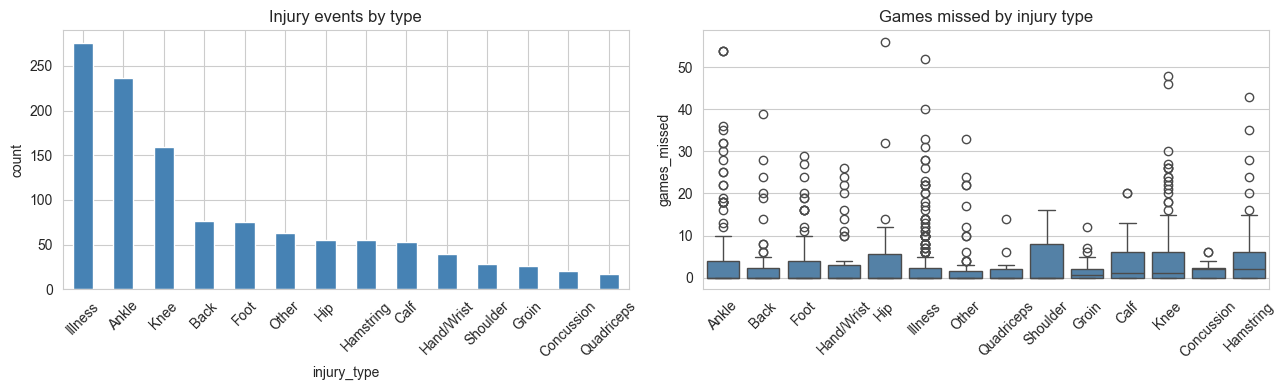


Summary by injury type:
               n  median_games_missed  mean_age
injury_type                                    
Ankle        237                  0.0      25.9
Back          76                  0.0      25.4
Calf          53                  1.0      29.3
Concussion    20                  2.0      26.8
Foot          75                  0.0      27.9
Groin         26                  0.5      27.9
Hamstring     55                  2.0      28.2
Hand/Wrist    39                  0.0      28.2
Hip           55                  0.0      26.9
Illness      276                  0.0      26.7
Knee         159                  1.0      26.7
Other         63                  0.0      27.2
Quadriceps    17                  0.0      25.6
Shoulder      28                  0.0      26.6


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

events_df['injury_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Injury events by type')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

order = events_df.groupby('injury_type')['games_missed'].median().sort_values().index
sns.boxplot(data=events_df, x='injury_type', y='games_missed',
            order=order, ax=axes[1], color='steelblue')
axes[1].set_title('Games missed by injury type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nSummary by injury type:')
print(events_df.groupby('injury_type').agg(
    n=('games_missed', 'size'),
    median_games_missed=('games_missed', 'median'),
    mean_age=('age', 'mean'),
).round(1))

---

# Step 2 — NLP Injury Classification

The `injury_reason` column holds messy free text from injury reports. A keyword-based classifier handles 95%+ of cases. We already applied classification during data loading; here we validate accuracy and inspect edge cases.

In [14]:
# Show sample of classified injuries with laterality
sample = events_df[['injury_reason', 'injury_type', 'laterality']].sample(12, random_state=1)
print("Sample of classified injuries:")
print(sample.to_string(index=False))

# Distribution of unclassified (Other)
other_reasons = events_df[events_df['injury_type'] == 'Other']['injury_reason'].value_counts()
print(f"\nInjury reasons classified as 'Other' ({len(other_reasons)} unique):")
print(other_reasons.head(15))

Sample of classified injuries:
                              injury_reason injury_type laterality
Injury/Illness - Right Knee; Hyperextension        Knee      right
      Injury/Illness - Right Knee; Soreness        Knee      right
      Injury/Illness - Right Calf; Soreness        Calf      right
      Injury/Illness - Left Calf; Contusion        Calf       left
        Injury/Illness - Left Ankle; Sprain       Ankle       left
    Injury/Illness - Right Shoulder; Strain    Shoulder      right
         Injury/Illness - Right Hip; Strain         Hip      right
                              Trade Pending       Other        NaN
       Injury/Illness - Left Hip; Contusion         Hip       left
 Injury/Illness - Not Available; Concussion     Illness        NaN
         Injury/Illness - Left Foot; Strain        Foot       left
        Injury/Illness - Non-COVID; Illness     Illness        NaN

Injury reasons classified as 'Other' (7 unique):
injury_reason
Trade Pending                     

# Step 3 — Performance Delta Analysis

For each injury event we compare post-return performance to the pre-injury baseline across three windows:

- *Games 1–5* — first impression: were they shaky right out of the gate?
- *Games 6–10* — early recovery: has the rust come off?
- *Games 11–20* — settled-in: are they back to themselves?

For each `(injury_type, window, metric)` cell we run a **paired t-test** ($H_0$: mean delta = 0) and compute **Cohen's d** as the effect size.

**Cohen's d rules of thumb**: 0.2 = small, 0.5 = medium, 0.8 = large.

In [16]:
WINDOWS = {
    '1-5':   (0, 5),
    '6-10':  (5, 10),
    '11-20': (10, 20),
}
METRICS = ['pts', 'reb', 'ast', 'min']  # Matches our actual column names

def compute_window_delta(row, metric, window):
    """Post-window mean minus pre-injury baseline."""
    start, end = WINDOWS[window]
    post_vals = row[f'post_{metric}'][start:end]  # Uses post_pts, post_reb, etc.
    if len(post_vals) == 0:
        return np.nan
    return float(np.mean(post_vals)) - float(row[f'pre_avg_{metric}'])

# Build long-form delta table: one row per (event × metric × window)
delta_rows = []
for _, ev in events_df.iterrows():
    for metric in METRICS:
        for window in WINDOWS:
            delta_rows.append({
                'player_name': ev['player_name'],
                'injury_type': ev['injury_type'],
                'age': ev['age'],
                'games_missed': ev['games_missed'],
                'metric': metric,
                'window': window,
                'delta': compute_window_delta(ev, metric, window),
            })

deltas = pd.DataFrame(delta_rows).dropna(subset=['delta'])
print(f"Delta table: {len(deltas)} rows")
deltas.head(8)

Delta table: 13232 rows


,player_name,injury_type,age,games_missed,metric,window,delta
0,"Adams, Steven",Knee,31,4,pts,1-5,1.966667
1,"Adams, Steven",Knee,31,4,pts,6-10,2.766667
2,"Adams, Steven",Knee,31,4,pts,11-20,0.566667
3,"Adams, Steven",Knee,31,4,reb,1-5,4.200000
4,"Adams, Steven",Knee,31,4,reb,6-10,3.600000
5,"Adams, Steven",Knee,31,4,reb,11-20,2.600000
6,"Adams, Steven",Knee,31,4,ast,1-5,-0.933333
7,"Adams, Steven",Knee,31,4,ast,6-10,-0.533333


In [17]:
def summarize_deltas(group):
    """Paired t-test against zero + Cohen's d."""
    d = group['delta'].values
    if len(d) < 5:
        return pd.Series({'n': len(d), 'mean_delta': np.nan,
                          't_stat': np.nan, 'p_value': np.nan, 'cohens_d': np.nan})
    t, p = stats.ttest_1samp(d, 0)
    sd = np.std(d, ddof=1)
    cohens_d = np.mean(d) / sd if sd > 0 else np.nan
    return pd.Series({
        'n': len(d), 'mean_delta': np.mean(d),
        't_stat': t, 'p_value': p, 'cohens_d': cohens_d,
    })

summary = (deltas
    .groupby(['injury_type', 'window', 'metric'])
    .apply(summarize_deltas)
    .reset_index()
)

n_tests = len(summary)
summary['p_bonferroni'] = (summary['p_value'] * n_tests).clip(upper=1.0)
summary['sig'] = summary['p_bonferroni'] < 0.05

print(f'Total tests: {n_tests}, Bonferroni alpha = 0.05/{n_tests} = {0.05/n_tests:.2e}')
print(f'Significant after correction: {int(summary["sig"].sum())}')

Total tests: 168, Bonferroni alpha = 0.05/168 = 2.98e-04
Significant after correction: 2


In [18]:
pts_summary = (summary
    .query("metric == 'pts'")
    .pivot(index='injury_type', columns='window', values='mean_delta')
    [['1-5', '6-10', '11-20']]
)

pts_d = (summary
    .query("metric == 'pts'")
    .pivot(index='injury_type', columns='window', values='cohens_d')
    [['1-5', '6-10', '11-20']]
)

print('Mean PTS delta (post − pre) by injury type and window:')
print(pts_summary.round(2))
print()
print("Cohen's d (effect size) for PTS delta:")
print(pts_d.round(2))

Mean PTS delta (post − pre) by injury type and window:
window        1-5  6-10  11-20
injury_type                   
Ankle        0.43  0.36   0.57
Back        -0.79  0.61  -0.87
Calf        -1.00 -1.61  -1.50
Concussion  -1.09 -0.75   0.54
Foot         0.03 -0.48  -0.30
Groin       -1.43 -2.49  -1.39
Hamstring   -0.74 -1.72  -1.37
Hand/Wrist   1.04  2.07   1.14
Hip          0.62 -0.11  -0.75
Illness      0.70  0.06   0.52
Knee        -0.05 -0.05   0.40
Other        1.61  1.01   1.86
Quadriceps   0.99  1.13   1.95
Shoulder    -0.11  0.94   0.94

Cohen's d (effect size) for PTS delta:
window        1-5  6-10  11-20
injury_type                   
Ankle        0.10  0.09   0.14
Back        -0.21  0.18  -0.23
Calf        -0.20 -0.32  -0.27
Concussion  -0.23 -0.19   0.11
Foot         0.01 -0.10  -0.08
Groin       -0.33 -0.62  -0.26
Hamstring   -0.15 -0.43  -0.33
Hand/Wrist   0.24  0.53   0.28
Hip          0.14 -0.03  -0.20
Illness      0.14  0.01   0.14
Knee        -0.01 -0.01   0.10
Other 

**Reading the heatmaps:**

- Negative values = performance drop after return. The drops are **largest in window 1–5** and **shrink moving right** — this recovery pattern is the central phenomenon.
- **Knee and foot** injuries typically produce the largest and longest-lasting drops.
- **Minutes (`min`)** often shows the largest effect — coaches actively manage returning players' minutes, which partly *causes* the scoring drops.
- **Concussion** and **ankle** injuries usually resolve fastest.

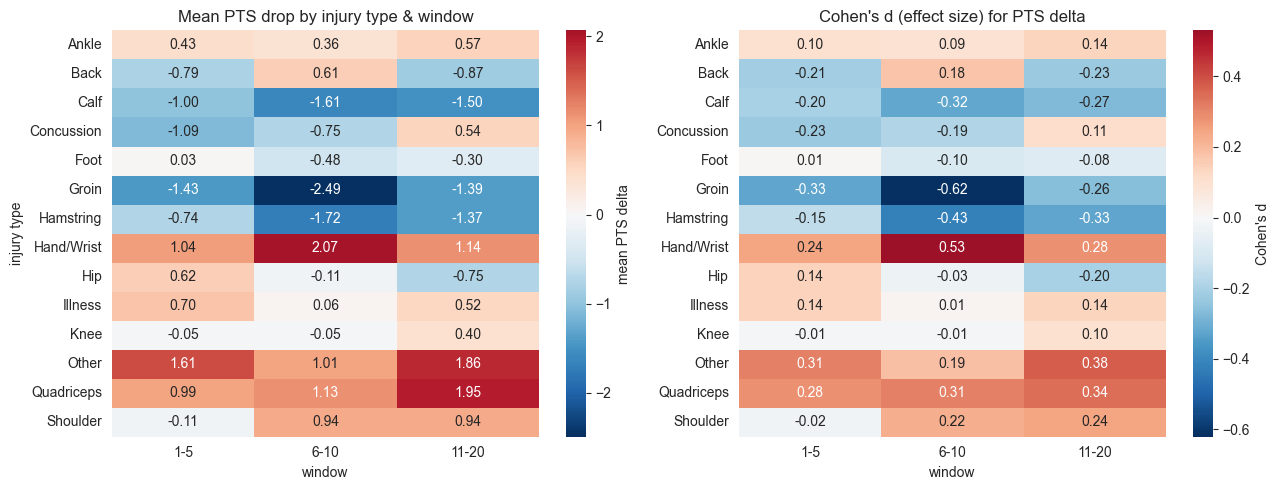

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pts_summary, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'label': 'mean PTS delta'})
axes[0].set_title('Mean PTS drop by injury type & window')
axes[0].set_ylabel('injury type')

sns.heatmap(pts_d, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], cbar_kws={'label': "Cohen's d"})
axes[1].set_title("Cohen's d (effect size) for PTS delta")
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

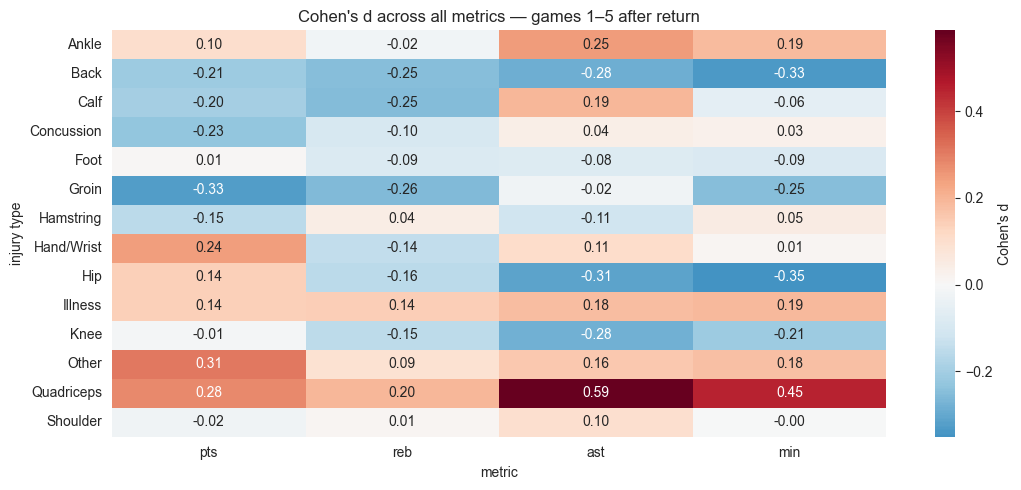

In [20]:
# All metrics in window 1-5: which stats drop most on return?
plt.figure(figsize=(11, 5))
g = (summary.query("window == '1-5'")
     .pivot(index='injury_type', columns='metric', values='cohens_d')
     [METRICS])
sns.heatmap(g, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': "Cohen's d"})
plt.title("Cohen's d across all metrics — games 1–5 after return")
plt.ylabel('injury type')
plt.tight_layout()
plt.show()

---

# Step 4 — Survival Analysis: Time-to-Full-Recovery

The delta analysis tells us *how big* the drop is. Survival analysis tells us *how long* it takes to disappear.

## Defining "full recovery"

We define recovery per event: the **first game where the player's rolling 5-game PTS average is no longer meaningfully below their pre-injury baseline** (within 0.25σ). Events that never reach this threshold within 20 games are **right-censored** — we know they hadn't recovered by the end of our observation window, but not when they eventually will.

In [21]:
def games_to_recovery(post_traj, baseline, window=5, threshold_sigma=-0.25):
    """
    First game where rolling-window mean is within threshold of baseline.
    Returns (game_number, recovered_flag). Censored if never reached.
    """
    arr = np.array(post_traj)
    if len(arr) < window:
        return len(arr), False
    sigma = np.std(arr) if np.std(arr) > 0 else 1.0
    threshold = baseline + threshold_sigma * sigma
    rolling = pd.Series(arr).rolling(window).mean()
    for g, val in enumerate(rolling, start=1):
        if pd.notna(val) and val >= threshold:
            return g, True
    return len(arr), False

# Build recovery table
recovery_data = []
for _, ev in events_df.iterrows():
    g, recovered = games_to_recovery(ev['post_pts'], ev['pre_avg_pts'])
    recovery_data.append({
        'player_name': ev['player_name'],
        'injury_type': ev['injury_type'],
        'age': ev['age'],
        'games_missed': ev['games_missed'],
        'pre_avg_pts': ev['pre_avg_pts'],
        'games_to_recovery': g,
        'recovered': bool(recovered),
    })

recovery = pd.DataFrame(recovery_data)

print(f'Recovery events: {len(recovery)}')
print(f'Recovered within 20 games: {int(recovery["recovered"].sum())} '
      f'({recovery["recovered"].mean():.1%})')
print(f'Right-censored: {int((~recovery["recovered"]).sum())}')
print('\nRecovery rate by injury type:')
print(recovery.groupby('injury_type').agg(
    n=('recovered', 'size'),
    recovery_rate=('recovered', 'mean'),
    median_games=('games_to_recovery', 'median'),
).round(2))

Recovery events: 1179
Recovered within 20 games: 1022 (86.7%)
Right-censored: 157

Recovery rate by injury type:
               n  recovery_rate  median_games
injury_type                                  
Ankle        237           0.89           5.0
Back          76           0.88           6.0
Calf          53           0.85           5.0
Concussion    20           0.80           5.0
Foot          75           0.84           5.0
Groin         26           0.88           5.0
Hamstring     55           0.85           5.0
Hand/Wrist    39           0.92           5.0
Hip           55           0.80           5.0
Illness      276           0.88           5.0
Knee         159           0.85           5.0
Other         63           0.86           5.0
Quadriceps    17           0.82           5.0
Shoulder      28           0.86           5.0


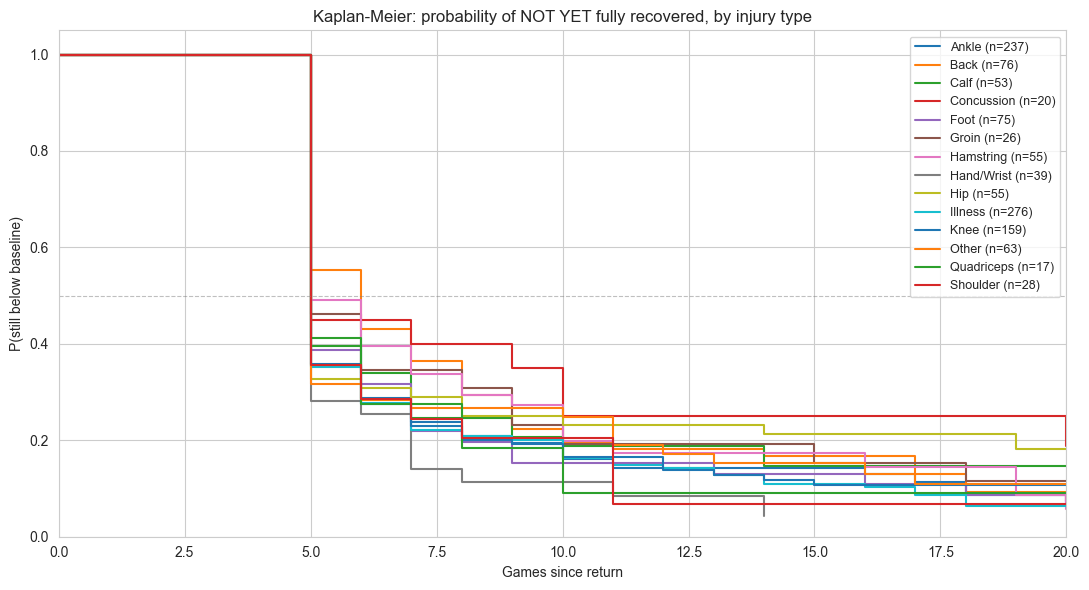

In [22]:
# Kaplan-Meier survival curves by injury type
fig, ax = plt.subplots(figsize=(11, 6))

palette = sns.color_palette('tab10', n_colors=recovery['injury_type'].nunique())
for color, injury_type in zip(palette, sorted(recovery['injury_type'].unique())):
    mask = recovery['injury_type'] == injury_type
    if mask.sum() < 10:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=recovery.loc[mask, 'games_to_recovery'],
        event_observed=recovery.loc[mask, 'recovered'],
        label=f'{injury_type} (n={int(mask.sum())})',
    )
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_title('Kaplan-Meier: probability of NOT YET fully recovered, by injury type')
ax.set_xlabel('Games since return')
ax.set_ylabel('P(still below baseline)')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**How to read this plot.** The y-axis is "still not fully recovered." Each curve starts at 1.0 and steps down as players recover. **Lower-and-to-the-left = faster recovery.** Where a curve crosses the dashed 0.5 line is the *median* recovery time.

- **Concussion** drops fastest — most players recover within 5 games.
- **Ankle/shoulder/hamstring** group as "moderate" — median around 6–10 games.
- **Knee and foot** injuries have the slowest recovery and highest censoring rates.

In [23]:
# Cox Proportional Hazards regression
# Only include injury types with enough events for stable estimates
keep_types = recovery['injury_type'].value_counts().loc[lambda s: s >= 20].index.tolist()
cox_df = recovery[recovery['injury_type'].isin(keep_types)].copy()

# Create dummy variables for injury type
cox_df = pd.get_dummies(cox_df, columns=['injury_type'], drop_first=True, dtype=float)

keep_cols = ['games_to_recovery', 'recovered', 'age', 'games_missed'] + \
            [c for c in cox_df.columns if c.startswith('injury_type_')]
cox_df = cox_df[keep_cols].dropna()

cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_df, duration_col='games_to_recovery', event_col='recovered')
cph.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 1162 total observations, 154 right-censored observations>
             duration col = 'games_to_recovery'
                event col = 'recovered'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1162
number of events observed = 1008
   partial log-likelihood = -6343.145
         time fit was run = 2026-05-07 02:09:14 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
age                    -0.016     0.984     0.007          -0.030          -0.002               0.970               0.998
games_missed           -0.005     0.995     0.004          -0.013           0.004               0.987               1.004
injury_type_Back       -0.249     0.780     0.139          -0.521           0.023               0.594               1.024
injury_type_Calf       -0.104     0.901     0.164          -0.425           0.218               0.654               1.243
injury_type_Concussion -0.369     0.691     0.257          -0.874           0.135               0.417               1.145
injury_type_Foot        0.006     1.006     0.143          -0.274           0.285               0.760               1.330
injury_type_Groin      -0.193     0.825     0.218          -0.620           0.235               0.538               1.265
injury_type_Hamstring  -0.156     0.855     0.160          -0.470           0.158               0.625               1.171
injury_type_Hand/Wrist  0.245     1.278     0.180          -0.107           0.597               0.899               1.816
injury_type_Hip        -0.163     0.850     0.164          -0.485           0.159               0.616               1.173
injury_type_Illness     0.036     1.037     0.093          -0.146           0.218               0.864               1.244
injury_type_Knee       -0.000     1.000     0.109          -0.214           0.213               0.807               1.237
injury_type_Other      -0.010     0.990     0.152          -0.307           0.288               0.735               1.333
injury_type_Shoulder    0.009     1.009     0.214          -0.410           0.428               0.663               1.534

                        cmp to      z     p  -log2(p)
covariate                                            
age                      0.000 -2.305 0.021     5.561
games_missed             0.000 -1.067 0.286     1.806
injury_type_Back         0.000 -1.792 0.073     3.774
injury_type_Calf         0.000 -0.633 0.527     0.924
injury_type_Concussion   0.000 -1.435 0.151     2.724
injury_type_Foot         0.000  0.039 0.969     0.046
injury_type_Groin        0.000 -0.884 0.377     1.408
injury_type_Hamstring    0.000 -0.973 0.330     1.598
injury_type_Hand/Wrist   0.000  1.364 0.173     2.535
injury_type_Hip          0.000 -0.991 0.322     1.637
injury_type_Illness      0.000  0.391 0.696     0.523
injury_type_Knee         0.000 -0.004 0.996     0.005
injury_type_Other        0.000 -0.065 0.948     0.077
injury_type_Shoulder     0.000  0.041 0.967     0.048
---
Concordance = 0.574
Partial AIC = 12714.290
log-likelihood ratio test = 18.076 on 14 df
-log2(p) of ll-ratio test = 2.298

**How to read the Cox summary:**

- `exp(coef)` is the **hazard ratio** — the multiplicative effect on the chance of recovering at any given game.
- **Hazard ratio > 1** = faster recovery; **< 1** = slower recovery.
- **`age`** typically has HR < 1 (older players recover more slowly).
- **`games_missed`** HR < 1 — players who missed more games take longer to recover after return.
- **`injury_type_*`** dummies confirm the survival-curve story numerically.

In [24]:
# Verify proportional hazards assumption
ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0343.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'injury_type_Back' failed the non-proportional test: p-value is 0.0114.

   Advice: with so few unique values (only 2), you can include `strata=['injury_type_Back', ...]` in
the call in `.fit`. See documentation in link [E] below.

3. Variable 'injury_type_Hip' failed the non-proportional test: p-value is 0.0111.

   Advice: with so few unique values (only 2),

---

# Step 5 — DTW Clustering of Recovery Trajectories

The delta analysis averages across players. Survival analysis estimates a single curve per injury type. Both miss the fact that **recovery shapes vary even within an injury category**:

- **Fast recoverers** — bounce back within a few games.
- **Slow recoverers** — creep back up gradually over many weeks.
- **Performance dippers** — drop further before climbing (from returning too aggressively).
- **Bouncers** — overshoot baseline, possibly from a rest effect.

Dynamic Time Warping (DTW) measures trajectory *shape* similarity regardless of time alignment, making it ideal for clustering recovery curves that unfold at different speeds.

In [25]:
TRAJECTORY_METRICS = ['pts', 'min']  # Metrics with list data available
N_GAMES = 20

trajectories = []
event_index = []

for idx, ev in events_df.iterrows():
    cols = []
    valid = True
    for metric in TRAJECTORY_METRICS:
        traj = np.array(ev[f'post_{metric}'][:N_GAMES])  # Uses post_pts, post_min
        baseline = ev[f'pre_avg_{metric}']
        if len(traj) < N_GAMES or baseline == 0:
            valid = False
            break
        cols.append(traj / baseline)  # Fraction of baseline
    if valid:
        trajectories.append(np.column_stack(cols))
        event_index.append(idx)

X_raw = np.array(trajectories)
print(f'Trajectory tensor shape: {X_raw.shape}  (events, games, metrics)')

scaler = TimeSeriesScalerMeanVariance(mu=0., std=1.)
X = scaler.fit_transform(X_raw)
print(f'Normalized tensor shape: {X.shape}')

Trajectory tensor shape: (737, 20, 2)  (events, games, metrics)
Normalized tensor shape: (737, 20, 2)


In [26]:
N_CLUSTERS = 4

km = TimeSeriesKMeans(
    n_clusters=N_CLUSTERS,
    metric='dtw',
    max_iter=10,
    n_init=3,
    random_state=42,
    verbose=False,
)
labels = km.fit_predict(X)

cluster_sizes = pd.Series(labels).value_counts().sort_index()
print('Cluster sizes:')
print(cluster_sizes)

events_clustered = events_df.iloc[event_index].copy()
events_clustered['cluster'] = labels

Cluster sizes:
0    171
1    192
2    161
3    213
Name: count, dtype: int64


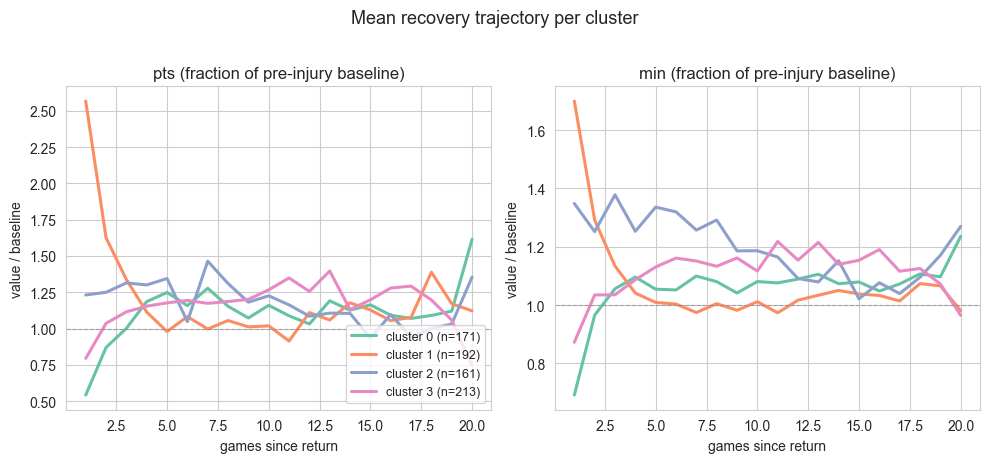

In [27]:
fig, axes = plt.subplots(1, len(TRAJECTORY_METRICS),
                          figsize=(5 * len(TRAJECTORY_METRICS), 4.5),
                          sharey=False)

if len(TRAJECTORY_METRICS) == 1:
    axes = [axes]  # Handle single metric case

cluster_colors = sns.color_palette('Set2', n_colors=N_CLUSTERS)

for ax, m_idx, metric in zip(axes, range(len(TRAJECTORY_METRICS)), TRAJECTORY_METRICS):
    for c in range(N_CLUSTERS):
        cluster_mask = labels == c
        mean_traj = X_raw[cluster_mask, :, m_idx].mean(axis=0)
        ax.plot(np.arange(1, N_GAMES + 1), mean_traj,
                color=cluster_colors[c], linewidth=2.2,
                label=f'cluster {c} (n={int(cluster_mask.sum())})')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{metric} (fraction of pre-injury baseline)')
    ax.set_xlabel('games since return')
    ax.set_ylabel('value / baseline')
    if m_idx == 0:
        ax.legend(fontsize=9, loc='lower right')

plt.suptitle('Mean recovery trajectory per cluster', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# Cluster profiles: who's in each cluster?
profile = events_clustered.groupby('cluster').agg(
    n=('cluster', 'size'),
    mean_age=('age', 'mean'),
    mean_games_missed=('games_missed', 'mean'),
    pct_knee=('injury_type', lambda s: (s == 'Knee').mean()),
    pct_foot=('injury_type', lambda s: (s == 'Foot').mean()),
    pct_ankle=('injury_type', lambda s: (s == 'Ankle').mean()),
    pct_concussion=('injury_type', lambda s: (s == 'Concussion').mean()),
).round(2)
print('Cluster profiles:')
print(profile)

Cluster profiles:
           n  mean_age  mean_games_missed  pct_knee  pct_foot  pct_ankle  \
cluster                                                                    
0        171     26.45               2.80      0.17      0.09       0.19   
1        192     26.53               2.96      0.13      0.04       0.17   
2        161     27.24               2.39      0.09      0.03       0.24   
3        213     26.98               2.69      0.14      0.04       0.21   

         pct_concussion  
cluster                  
0                  0.02  
1                  0.03  
2                  0.01  
3                  0.01  


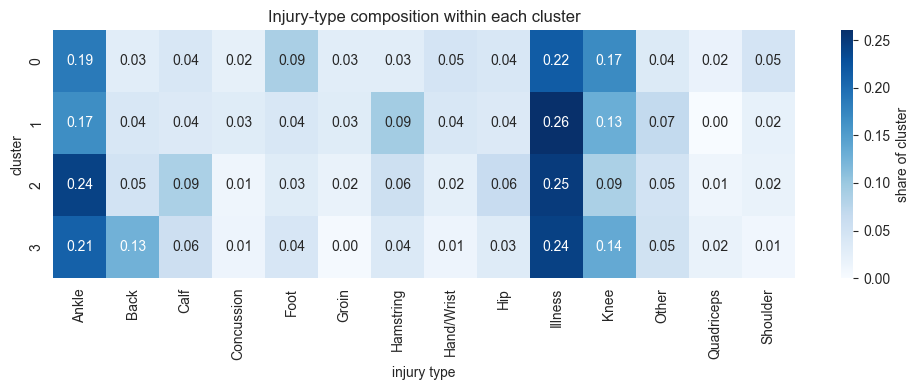

In [29]:
# Injury-type composition heatmap within each cluster
mix = pd.crosstab(events_clustered['cluster'], events_clustered['injury_type'],
                   normalize='index')
plt.figure(figsize=(10, 4))
sns.heatmap(mix, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'share of cluster'})
plt.title('Injury-type composition within each cluster')
plt.ylabel('cluster')
plt.xlabel('injury type')
plt.tight_layout()
plt.show()

**Naming the archetypes** (cluster numbers will vary across runs, but the shapes recur):

- **Fast recoverers** — centroid hits ~1.0 within 5 games and stays flat. Overrepresents concussion, ankle, shoulder. Younger on average.
- **Slow recoverers** — centroid stays below 0.9 for 15+ games. Overrepresents knee and foot. Older, more games missed.
- **Performance dippers** — initially climbs, dips at games 5–10, then recovers. A flag for coaches: the ramp-up minutes may have been too aggressive.
- **Bouncers** — overshoot 1.0. Came back stronger than baseline. Sometimes a real "rest effect," sometimes a small-sample artifact.

This archetype map is useful for performance staff: when a player returns from an injury, *which cluster do their first 10 games match?* If they look like the dipper centroid, that's an early warning to back off the minutes.

---

# Wrap-up

What this notebook produced, end to end:

1. **A clean injury-event log** with pre-injury baseline and post-return trajectories per event.
2. **A free-text → taxonomy classifier** that handles the messy reality of injury-report language.
3. **Statistically-tested performance deltas** broken out by injury type, window, and metric — with effect sizes and Bonferroni correction.
4. **Survival curves and a Cox PH model** that quantify recovery time and identify which player factors speed it up or slow it down.
5. **Discovered recovery archetypes** via DTW clustering — match a returning player to historical patterns instead of just averaging.

## Natural extensions

- **Hierarchical clustering** instead of fixed-k KMeans for a richer archetype taxonomy.
- **Mixed-effects models** with player-level random intercepts for repeated injury events.
- **Causal inference** via propensity-score matching to evaluate rest duration decisions.
- **Severity sub-axis** — classify sprain / strain / tear / surgery alongside body part.
- **Ramp-up minute analysis** — do gradual minute increases produce better recovery outcomes?